In [311]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import product

In [312]:
df = pd.read_excel("./data/CleanSecurityData.xlsx")

df["Date"] = pd.to_datetime(df["date"])
df = df.sort_values(["cusip", "Date"])

df["delta_spread"] = df.groupby("cusip")["spread"].diff()
df = df[["cusip", 'coupon_rate', 'spread', 'closing_price', 'current_yield', 'ytm', 'duration', 'ttm', 'dts', 'Date', 'delta_spread']].dropna()

In [313]:
IQR = df['spread'].describe()['75%'] - df['spread'].describe()['25%']
L = df['spread'].describe()['25%'] - 1.5 * IQR
U = df['spread'].describe()['75%'] + 1.5 * IQR

df = df[(df['spread'] > L) & (df['spread'] < U)]

In [314]:


sb1 = df["spread"].quantile(0.33)
sb2 = df["spread"].quantile(0.66)

df["spread_bucket"] = np.where(df["spread"] < sb1, "0",
                        np.where(df["spread"] < sb2, "1", "2"))

db1 = df["duration"].quantile(0.33)
db2 = df["duration"].quantile(0.66)

df["duration_bucket"] = np.where(df["duration"] < db1, "0",
                        np.where(df["duration"] < db2, "1", "2"))


In [315]:
parameters = {}
residuals = {}
medians = {}
sys_spread_chg = pd.DataFrame(columns=["month", "duration_bucket", "sys_change", "medians"])
j = 0
for month_bucket, df_temp in df.groupby(df['Date'].dt.to_period('M')):
    #(a,b) = month_bucket
    
    X = sm.add_constant(df_temp["spread"] - np.mean(df_temp["spread"]))
    y = df_temp["delta_spread"]
    model = sm.OLS(y, X).fit()
    parameters[month_bucket] = (model.params['const'], model.params['spread'])
    residuals[month_bucket] = model.resid
    medians[month_bucket] = np.median(df_temp["spread"])
    #sys_spread_chg.loc[j] = [a,b,np.mean(model.fittedvalues), np.median(df_temp["spread"])]
    j+=1

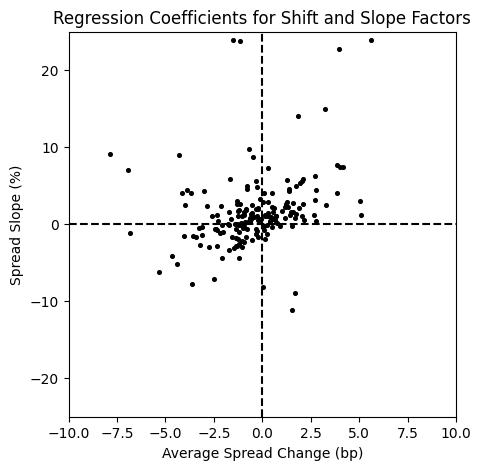

In [316]:
plt.figure(figsize = (5,5))
for i in parameters:
    (a,b) = parameters.get(i)
    plt.scatter(a*10000,b*100, color = 'black', s = 7)
    
plt.axhline(0, color = 'black', ls = '--')
plt.axvline(0, color = 'black', ls = '--')
plt.title('Regression Coefficients for Shift and Slope Factors')
plt.ylabel('Spread Slope (%)')
plt.xlabel('Average Spread Change (bp)')
ax = plt.gca()
ax.set_ylim([-25, 25])
ax.set_xlim([-.001*10000, .001*10000])

plt.show()

should have a strong linear spread - doesnt because we cannot break our data into sectors

In [374]:
sb1 = df["spread"].quantile(0.2)
sb2 = df["spread"].quantile(0.4)
sb3 = df["spread"].quantile(0.6)
sb4 = df["spread"].quantile(0.8)

df["spread_bucket"] = np.where(df["spread"] < sb1, "0",
                        np.where(df["spread"] < sb2, "1", 
                        np.where(df["spread"] < sb3, "2",
                        np.where(df["spread"] < sb4, "3", "4"))))

db1 = df["duration"].quantile(0.2)
db2 = df["duration"].quantile(0.4)
db3 = df["duration"].quantile(0.6)
db4 = df["duration"].quantile(0.8)

df["duration_bucket"] = np.where(df["duration"] < db1, "0",
                        np.where(df["duration"] < db2, "1", 
                        np.where(df["duration"] < db3, "2",
                        np.where(df["duration"] < db4, "3", "4"))))

In [404]:
parameters = {}
residuals = {}
medians = {}
sys_spread_chg = pd.DataFrame(columns=["month", "duration_bucket", 'spread_bucket',"sys_change", "medians"])
idio_spread_chg = pd.DataFrame(columns=["month", "duration_bucket", 'spread_bucket',"idio_change", "medians"])
j = 0
for month_bucket, df_temp in df.groupby([df['Date'].dt.to_period('M'), 'duration_bucket', 'spread_bucket']):
    a,b,c = month_bucket
    
    X = sm.add_constant(df_temp["spread"] - np.mean(df_temp["spread"]))
    y = df_temp["delta_spread"]
    model = sm.OLS(y, X).fit()
    parameters[month_bucket] = (model.params['const'], model.params['spread'])
    residuals[month_bucket] = model.resid
    medians[month_bucket] = np.median(df_temp["spread"])
    sys_spread_chg.loc[j] = [a,b,c,np.mean(model.fittedvalues), np.median(df_temp["spread"])]
    idio_spread_chg.loc[j] = [a,b,c,np.mean(model.resid), np.median(df_temp["spread"])]
    j+=1

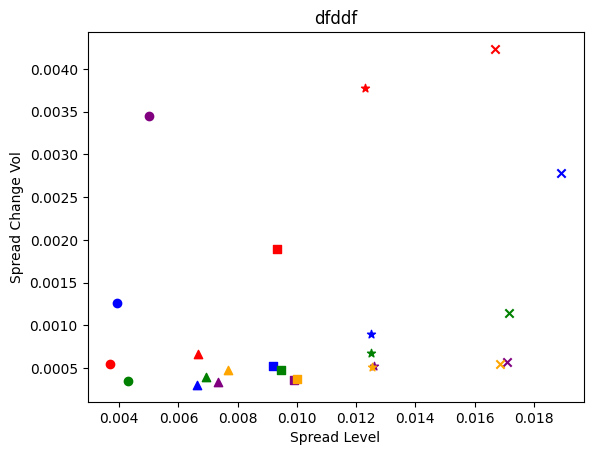

In [363]:
shapes = ['o', '^', 's', '*', 'x']
colors = ['red', 'blue', 'green', 'purple', 'orange']
for i,j in product(['0','1','2','3','4'],repeat=2):
    temp_df = sys_spread_chg[(sys_spread_chg['duration_bucket'] == i) & (sys_spread_chg['spread_bucket'] == j)]
    
    if len(temp_df) == 0:
        continue

    a = np.mean(temp_df['medians'])
    b = np.sqrt(1 / (len(temp_df['sys_change']) - 1) * np.sum((temp_df['sys_change'])**2))
    #b = temp_df['sys_change'].std()
    plt.scatter(a,b, c = colors[int(i)], marker=shapes[int(j)])


plt.xlabel('Spread Level')
plt.ylabel('Spread Change Vol')
plt.title('dfddf')
plt.show()

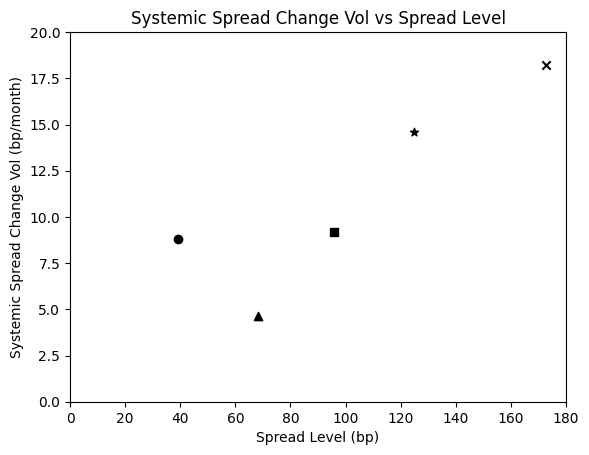

In [406]:
shapes = ['o', '^', 's', '*', 'x']
colors = ['red', 'blue', 'green', 'purple', 'orange']
for j in ['0','1','2','3','4']:
    temp_df = sys_spread_chg[ (sys_spread_chg['spread_bucket'] == j)]
    
    if len(temp_df) == 0:
        continue

    a = np.mean(temp_df['medians']*10000)
    b = np.sqrt(1 / (len(temp_df['sys_change']) - 1) * np.sum((temp_df['sys_change'] - np.mean(temp_df['sys_change']))**2))
    #b = temp_df['sys_change'].std()
    plt.scatter(a,(b*10000), c = 'black', marker=shapes[int(j)])


plt.xlabel('Spread Level (bp)')
plt.ylabel('Systemic Spread Change Vol (bp/month)')
plt.title('Systemic Spread Change Vol vs Spread Level')
ax = plt.gca()
ax.set_ylim([0,20])
ax.set_xlim([0, 180])
plt.show()

In [393]:
idio_vol = {}
for i in residuals:
    resids = residuals.get(i)
    if len(resids) < 2:
        continue
    idio_vol[i] = np.sqrt(1 / (len(resids) - 1) * np.sum((resids - np.mean(resids))**2))

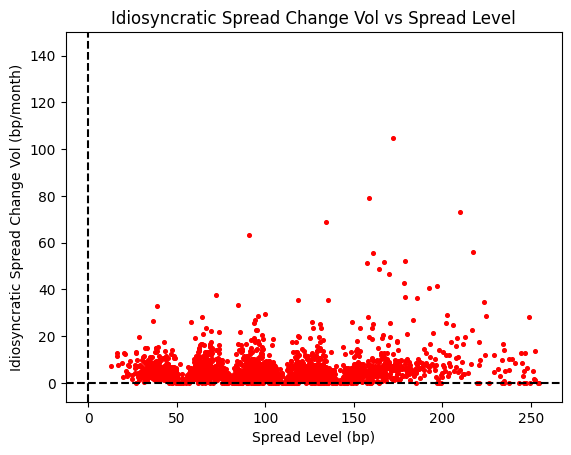

In [ ]:
for i in parameters:
    med = medians.get(i)
    vol = idio_vol.get(i)

    
    if vol:
        plt.scatter(med * 10000, vol * 10000, color = 'red', s = 7)
    
plt.axhline(0, color = 'black', ls = '--')
plt.axvline(0, color = 'black', ls = '--')
plt.xlabel('Spread Level (bp)')
plt.ylabel('Idiosyncratic Spread Change Vol (bp/month)')
plt.title('Idiosyncratic Spread Change Vol vs Spread Level')
ax = plt.gca()
ax.set_ylim([-8,150])
#ax.set_xlim([-.0025, .0025])
plt.show()

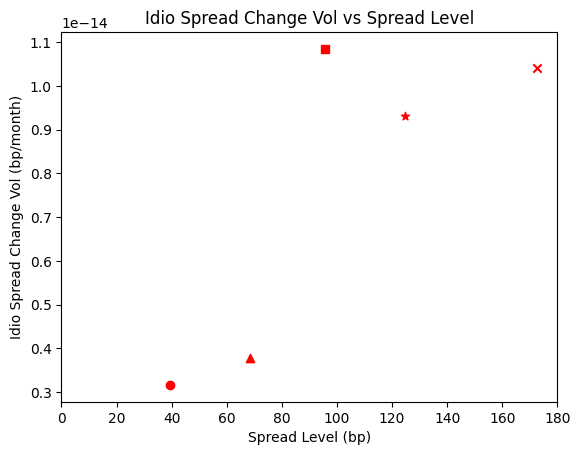

In [408]:
shapes = ['o', '^', 's', '*', 'x']
colors = ['red', 'blue', 'green', 'purple', 'orange']
for j in ['0','1','2','3','4']:
    temp_df = idio_spread_chg[ (sys_spread_chg['spread_bucket'] == j)]
    
    if len(temp_df) == 0:
        continue

    a = np.mean(temp_df['medians']*10000)
    b = np.sqrt(1 / (len(temp_df['idio_change']) - 1) * np.sum((temp_df['idio_change'] - np.mean(temp_df['idio_change']))**2))
    #b = temp_df['sys_change'].std()
    plt.scatter(a,(b*10000), c = 'red', marker=shapes[int(j)])


plt.xlabel('Spread Level (bp)')
plt.ylabel('Idio Spread Change Vol (bp/month)')
plt.title('Idio Spread Change Vol vs Spread Level')
ax = plt.gca()
ax.set_xlim([0, 180])
plt.show()

first graph that kinda looks like the paper 🥳🥳🥳

at this point we should easily see that both idiosyncratic and systemic spread changes are proportional to the level of spread 🥶🥶🥶🥶🥶🥶🥶🥶🥶

because of the above which is of course true that we found, vol of excess returns should be linearly related to dts

In [366]:
#set up duration quintiles then spread sixtiles for each month
#average excess returns and median dts
#time series vol excess returns and avg dts 

df["returns"] = df.groupby("cusip")["closing_price"].diff()
df = df.dropna()


In [367]:
sb1 = df["spread"].quantile(0.33)
sb2 = df["spread"].quantile(0.66)

df["spread_bucket"] = np.where(df["spread"] < sb1, "0",
                        np.where(df["spread"] < sb2, "1", "2"))

db1 = df["duration"].quantile(0.33)
db2 = df["duration"].quantile(0.66)

df["duration_bucket"] = np.where(df["duration"] < db1, "0",
                        np.where(df["duration"] < db2, "1", "2"))

In [375]:
excess_rets = pd.DataFrame(columns = ['month', 'duration_bucket', 'spread_bucket', 'excess_returns', 'dts_med'])
j = 0
for month_bucket, df_temp in df.groupby([df['Date'].dt.to_period('M'), 'duration_bucket', 'spread_bucket']):
    (a,b,c) = month_bucket
    
    excess_return = np.mean(df_temp['returns'] - df_temp['duration'] * df_temp['current_yield'])

    excess_rets.loc[j] = [a,b,c,excess_return, np.median(df_temp['dts'])]

    j+=1

In [369]:
excess_rets

,month,duration_bucket,spread_bucket,excess_returns,dts_med
0,2009-08,1,2,-43.323292,0.144222
1,2009-08,2,1,-76.229958,0.145756
2,2009-08,2,2,-76.143751,0.213433
3,2009-09,1,2,-44.636663,0.115476
4,2009-09,2,1,-77.743586,0.161947
...,...,...,...,...,...
1157,2024-11,1,1,-41.542347,0.082577
1158,2024-11,1,2,-62.694478,0.159638
1159,2024-11,2,0,-67.950679,0.099994
1160,2024-11,2,1,-69.418975,0.119131


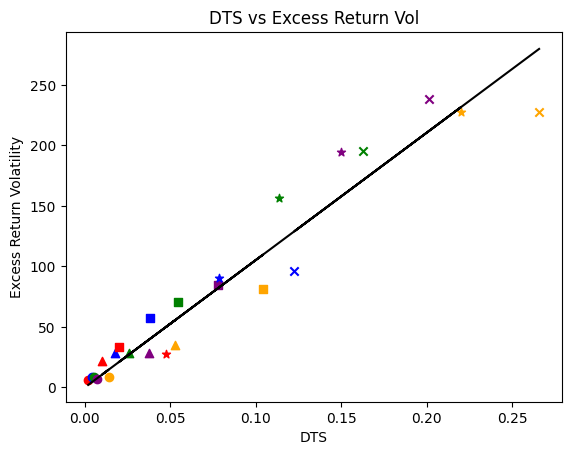

In [378]:
linregarea = pd.DataFrame(columns = ['x','y'])
shapes = ['o', '^', 's', '*', 'x']
colors = ['red', 'blue', 'green', 'purple', 'orange']
k = 0
for i,j in product(['0','1','2','3','4'], repeat=2):
    temp_df = excess_rets[(excess_rets['duration_bucket'] == i)&(excess_rets['spread_bucket'] == j)]
    
    if len(temp_df) == 0:
        continue

    a = np.mean(temp_df['dts_med'])
    b = np.sqrt(1 / (len('excess_returns') - 1) * np.sum((temp_df['excess_returns'])**2))
    linregarea.loc[k] = [a,b]
    k+=1
    plt.scatter(a,b, c = colors[int(j)], marker=shapes[int(i)])

m,b = np.polyfit(linregarea['x'], linregarea['y'], 1)

plt.plot(linregarea['x'], (m+40) * (linregarea['x']), '-', c = 'black')
plt.xlabel('DTS')
plt.ylabel('Excess Return Volatility')
plt.title('DTS vs Excess Return Vol')
plt.show()